In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('FuelConsumptionCo2.csv')

In [4]:
df.head()
# df.corr()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [5]:
# Drop Catagorical Data
df = df.drop(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE'], axis=1)
df.corr()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


In [6]:
df = df.drop(['CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_HWY'], axis=1)
df.head()

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,33,196
1,2.4,29,221
2,1.5,48,136
3,3.5,25,255
4,3.5,27,244


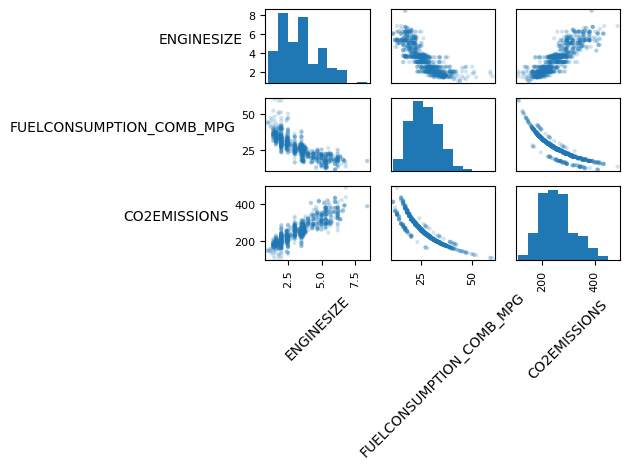

In [7]:
# To help with selecting predictive features that are not redundant, consider the following scatter matrix, which shows the scatter plots for each pair of input features. The diagonal of the matrix shows each feature's histogram.

axes = pd.plotting.scatter_matrix(df, alpha=0.2)

for ax in axes.flatten():
    ax.xaxis.label.set_rotation(45)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0.2, hspace=0.2)
plt.show()

In [8]:
X = df[['ENGINESIZE', 'FUELCONSUMPTION_COMB_MPG']]
y = df['CO2EMISSIONS']

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
pd.DataFrame(X_scaled, columns=X.columns).describe().round(2)

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG
count,1067.00,1067.00
mean,0.00,-0.00
std,1.00,1.00
min,-1.66,-2.07
25%,-0.95,-0.73
50%,0.04,-0.06
75%,0.67,0.61
max,3.57,4.50


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()

LR.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
print("Coefficients:", LR.coef_)
print("Intercept:", LR.intercept_)

Coefficients: [ 25.27339614 -37.4381472 ]
Intercept: 256.2907248808642


In [16]:
means = scaler.mean_
std = scaler.scale_

coef_original = LR.coef_ / std

intercept_original = (
    LR.intercept_
    - np.sum((means * LR.coef_) / std)
)

print("Original Coefficients:", coef_original)
print("Original Intercept:", intercept_original)

Original Coefficients: [17.8581369  -5.01502179]
Original Intercept: 329.1363967025387


In [17]:
y_pred = LR.predict(X_test)

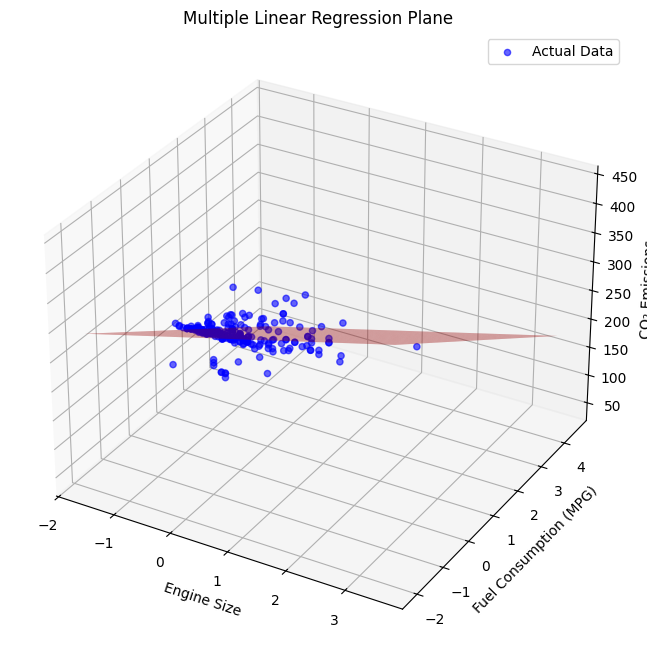

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Predict values
y_pred = LR.predict(X_test)

# Create Figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot (Actual Data)
ax.scatter(
    X_test[:, 0],
    X_test[:, 1],
    y_test,
    color='blue',
    alpha=0.6,
    label='Actual Data'
)

# Create Regression Plane
x1 = np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), 30)
x2 = np.linspace(X_test[:, 1].min(), X_test[:, 1].max(), 30)

x1_grid, x2_grid = np.meshgrid(x1, x2)

y_plane = (
    LR.intercept_
    + LR.coef_[0] * x1_grid
    + LR.coef_[1] * x2_grid
)

# Plot Regression Plane
ax.plot_surface(
    x1_grid,
    x2_grid,
    y_plane,
    alpha=0.4,
    color='red'
)

# Labels
ax.set_xlabel("Engine Size")
ax.set_ylabel("Fuel Consumption (MPG)")
ax.set_zlabel("CO₂ Emissions")

ax.set_title("Multiple Linear Regression Plane")

ax.legend()

plt.show()

c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


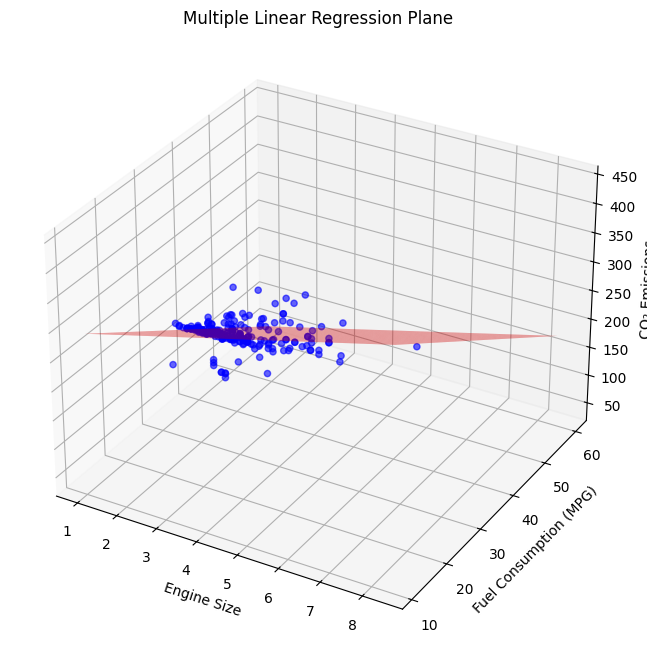

In [23]:
# Convert standardized features back to original values
X_test_original = scaler.inverse_transform(X_test)

# Predictions
y_pred = LR.predict(X_test)

# Create Figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(
    X_test_original[:, 0],
    X_test_original[:, 1],
    y_test,
    color='blue',
    alpha=0.6,
    label='Actual Data'
)

# Regression Plane
x1 = np.linspace(X_test_original[:, 0].min(), X_test_original[:, 0].max(), 30)
x2 = np.linspace(X_test_original[:, 1].min(), X_test_original[:, 1].max(), 30)

x1_grid, x2_grid = np.meshgrid(x1, x2)

# Scale grid because model was trained on standardized features
grid_scaled = scaler.transform(
    np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
)

y_plane = LR.predict(grid_scaled).reshape(x1_grid.shape)

# Plot Plane
ax.plot_surface(
    x1_grid,
    x2_grid,
    y_plane,
    alpha=0.4,
    color='red'
)

ax.set_xlabel("Engine Size")
ax.set_ylabel("Fuel Consumption (MPG)")
ax.set_zlabel("CO₂ Emissions")
ax.set_title("Multiple Linear Regression Plane")

plt.show()